In [38]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;

In [39]:
df=pd.read_csv("/Users/satyam/Desktop/machine lerning /classes/Introduction_To_Machine_Learning/Data/mpg.csv")

In [40]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [41]:
df=df.drop(columns=['name','origin'])
df['horsepower']=df['horsepower'].fillna(df['horsepower'].median())
print(df.shape,"|",df.isna().sum(),"missing")
df.head()

(398, 7) | mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
dtype: int64 missing


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [42]:
X=df.drop(columns='mpg')
y=df['mpg']

In [43]:

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2
,random_state=42)
print(X.shape,y.shape)

(398, 6) (398,)


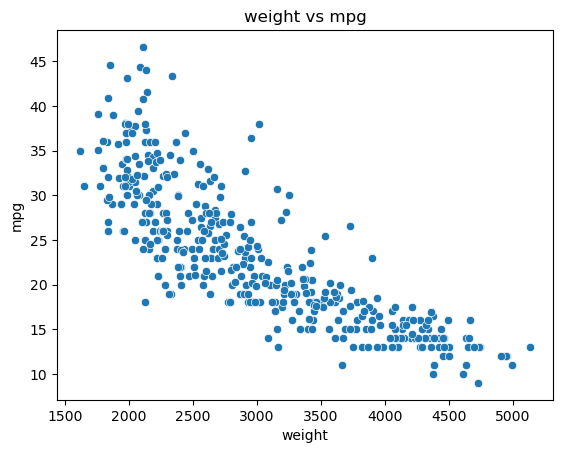

In [44]:
import seaborn as sns
sns.scatterplot(data=df,x='weight',y='mpg')
plt.title('weight vs mpg')
plt.show()

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train[['weight']], y_train) 
print("Coefficient: ", model.coef_)   
print("Intercept:   ", model.intercept_)


Coefficient:  [-0.00780524]
Intercept:    46.7820633664505


In [46]:
print(model.score(X_test[['weight']],y_test))

0.7229710573030748


<Axes: xlabel='weight', ylabel='mpg'>

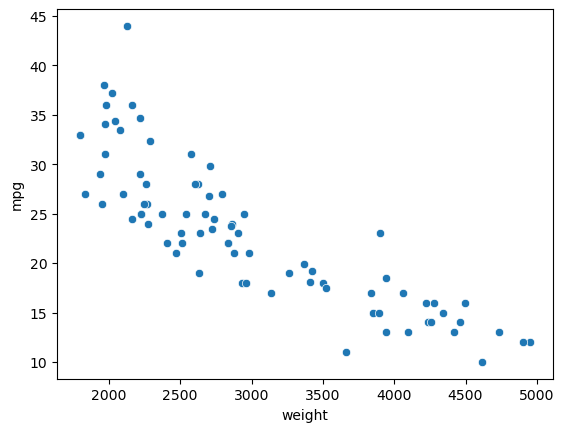

In [47]:
sns.scatterplot(x=X_test['weight'],y=y_test)

In [48]:
import pandas as pd

marks = pd.Series(
    [78, 92, 65, 88, 74, 95, 81, 69, 87, 76,
     90, 62, 84, 71, 93, 80, 67, 89, 73, 96,
     85, 77, 91, 68, 82, 75, 94, 70, 86, 79,
     83, 97, 64, 72, 88, 81, 69, 92, 76, 85],
    
    index=[
        "Aarav", "Vivaan", "Aditya", "Arjun", "Reyansh",
        "Krishna", "Ishaan", "Shaurya", "Atharv", "Kabir",
        "Ayaan", "Dhruv", "Rudra", "Vihaan", "Aadi",
        "Aryan", "Kian", "Rohan", "Yuvaan", "Dev",
        "Arnav", "Veer", "Anay", "Ritvik", "Parth",
        "Laksh", "Advait", "Neil", "Om", "Raghav",
        "Samar", "Vivaan2", "Harsh", "Kartik", "Manav",
        "Ayush", "Nakul", "Raj", "Siddharth", "Varun"
    ]
)

print(marks)

Aarav        78
Vivaan       92
Aditya       65
Arjun        88
Reyansh      74
Krishna      95
Ishaan       81
Shaurya      69
Atharv       87
Kabir        76
Ayaan        90
Dhruv        62
Rudra        84
Vihaan       71
Aadi         93
Aryan        80
Kian         67
Rohan        89
Yuvaan       73
Dev          96
Arnav        85
Veer         77
Anay         91
Ritvik       68
Parth        82
Laksh        75
Advait       94
Neil         70
Om           86
Raghav       79
Samar        83
Vivaan2      97
Harsh        64
Kartik       72
Manav        88
Ayush        81
Nakul        69
Raj          92
Siddharth    76
Varun        85
dtype: int64


In [49]:
print(marks["Arjun"])

88


In [50]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_train_scaled,X_test_scaled.shape)

[[ 1.52718818  1.0901965   1.26582056  0.55282624 -1.31933367 -1.6966673 ]
 [-0.85051483 -0.92299623 -0.40863468 -0.99966729 -0.41318225 -1.6966673 ]
 [-0.85051483 -0.98134964 -0.94878153 -1.1247723   0.92792185  1.63897537]
 ...
 [-0.85051483 -0.56315019 -0.21958328 -0.54094894 -0.30444408  0.52709448]
 [-0.85051483 -1.00080078 -1.11082559 -1.09498539  0.60170734  1.36100515]
 [-0.85051483 -0.92299623 -1.54294307 -1.21413301  1.94281144 -0.86275663]] (80, 6)


In [51]:
# the earlier model used only 'weight', so train one on ALL features to compare against
model_all = LinearRegression()
model_all.fit(X_train, y_train)

# same features, but standardised
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

print("without scaling:", model_all.score(X_test, y_test))
print("with scaling   :", model_scaled.score(X_test_scaled, y_test))

# The two scores are the same. Scaling shifts and stretches the columns, and plain
# Linear Regression just rescales its coefficients to match, so the fit is unchanged.
# Scaling matters for models that use distances or penalties (KNN, Ridge/Lasso, SVM).

without scaling: 0.8244245330943364
with scaling   : 0.8244245330943359


In [52]:
pd.DataFrame({
    'feature':X_test.columns,
    'coef without scaling ': model_all.coef_.round(3),
    'coef with scaling ':model_scaled.coef_.round(3)
})

,feature,coef without scaling,coef with scaling
0,cylinders,0.069,0.116
1,displacement,0.002,0.165
2,horsepower,0.003,0.107
3,weight,-0.007,-5.912
4,acceleration,0.081,0.222
5,model_year,0.801,2.883


In [53]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()
knn.fit(X_train,y_train)
acc_knn_raw=knn.score(X_test,y_test)
acc_knn_scaled=acc_knn_scaled(X_test,y_test)
print(acc_knn_scaled)
print(acc_knn_raw)

NameError: name 'acc_knn_scaled' is not defined

In [ ]:
pd.DataFrame({
    'model':['linear regreassion',
    
    'knn regreassor (no scaling )',
    
    'knn regressor (scaled)'],
    "R2": [round(model)]
})

TypeError: type LinearRegression doesn't define __round__ method